In [1]:
import matplotlib.pyplot as plt
import pickle
import os
import sys
sys.path.append("..")
from Evaluate.dqn_adapter import DQNPolicyWrapper
from eval import eval_policy
import numpy as np
from tqdm import tqdm
import random
import torch

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)



## Model-Based

In [2]:
dirs_to_load = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/VI/3_0.2_0.9_0.25/tracked_results.pkl", "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/PI/3_0.9_0.25/tracked_results.pkl"]

In [3]:
all_res = []
for dir in dirs_to_load:
    with open(dir, 'rb') as f:
        tracked_results = pickle.load(f)

    all_res.append(tracked_results)
    

In [4]:
all_res[1]

{'baseline_results': [{'win_rate': 0.4854,
   'draw_rate': 0.2636,
   'loss_rate': 0.251},
  {'win_rate': 0.4044, 'draw_rate': 0.218, 'loss_rate': 0.3776},
  {'win_rate': 0.5272, 'draw_rate': 0.1912, 'loss_rate': 0.2816},
  {'win_rate': 0.6374, 'draw_rate': 0.1922, 'loss_rate': 0.1704},
  {'win_rate': 0.6506, 'draw_rate': 0.1726, 'loss_rate': 0.1768},
  {'win_rate': 0.6414, 'draw_rate': 0.1942, 'loss_rate': 0.1644},
  {'win_rate': 0.5584, 'draw_rate': 0.319, 'loss_rate': 0.1226},
  {'win_rate': 0.4438, 'draw_rate': 0.4188, 'loss_rate': 0.1374}],
 'random_results': [{'win_rate': 0.7974,
   'draw_rate': 0.0666,
   'loss_rate': 0.136},
  {'win_rate': 0.7382, 'draw_rate': 0.0828, 'loss_rate': 0.179},
  {'win_rate': 0.799, 'draw_rate': 0.1006, 'loss_rate': 0.1004},
  {'win_rate': 0.8124, 'draw_rate': 0.095, 'loss_rate': 0.0926},
  {'win_rate': 0.8298, 'draw_rate': 0.0922, 'loss_rate': 0.078},
  {'win_rate': 0.8336, 'draw_rate': 0.082, 'loss_rate': 0.0844},
  {'win_rate': 0.836, 'draw_rate':

In [ ]:
def plot_results(results_dict, title):
    baseline = results_dict['baseline_results']
    random = results_dict['random_results']

    baseline_win_rates = [x['win_rate'] for x in baseline]
    random_win_rates = [x['win_rate'] for x in random]

    baseline_draw_rates = [x['draw_rate'] for x in baseline]
    random_draw_rates = [x['draw_rate'] for x in random]

    baseline_loss_rates = [x['loss_rate'] for x in baseline]
    random_loss_rates = [x['loss_rate'] for x in random]

    iterations = results_dict['iter_at_eval']
    # iterations is already [iteration_number, cumulative_updates/actions]
    # Use the second column directly - it's already cumulative!
    iteration_steps = [it[1] for it in iterations]

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].set_title('Baseline Rates')
    ax[0].plot(iteration_steps, baseline_win_rates, label='Win Rate')
    ax[0].plot(iteration_steps, baseline_draw_rates, label='Draw Rate')
    ax[0].plot(iteration_steps, baseline_loss_rates, label='Loss Rate')
    ax[0].set_xlabel('Cumulative Updates/Actions')
    ax[0].legend()
    ax[0].set_ylabel('Rate')

    ax[1].set_title('Random Rates')
    ax[1].plot(iteration_steps, random_win_rates, label='Win Rate')
    ax[1].plot(iteration_steps, random_draw_rates, label='Draw Rate')
    ax[1].plot(iteration_steps, random_loss_rates, label='Loss Rate')
    ax[1].set_xlabel('Cumulative Updates/Actions')

    ax[1].legend()
    ax[1].set_ylabel('Rate')

    fig.suptitle(title)

    plt.show()


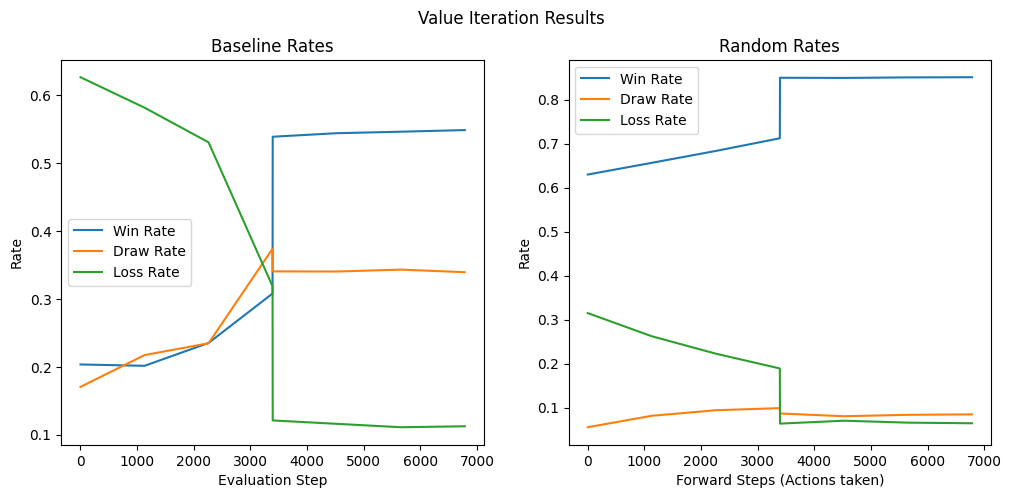

In [6]:
plot_results(all_res[0], "Value Iteration Results")

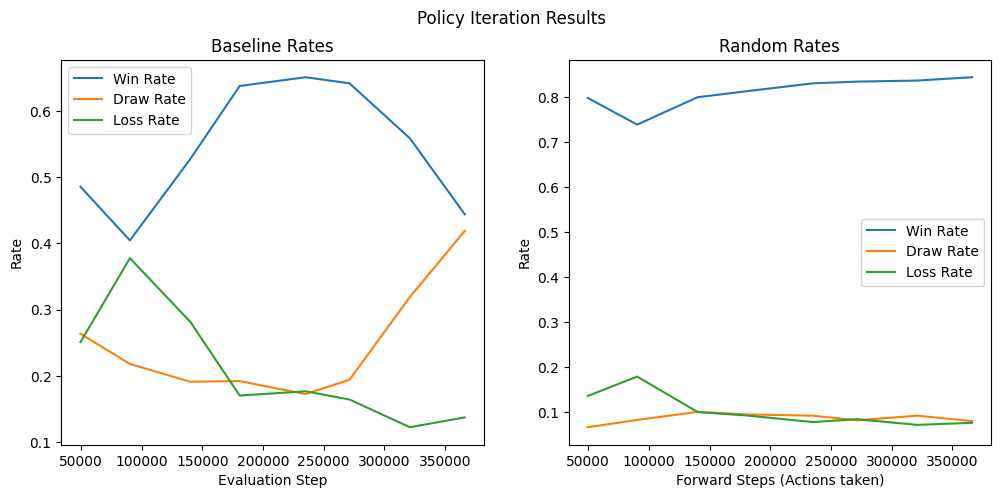

In [7]:
plot_results(all_res[1], "Policy Iteration Results")

## DQN

In [8]:
#dirs = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/5_1_0.25_winner/q_network.pt",
#        "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/7_1_0.25_winner/q_network.pt",
#        "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/3_1_0.25_winner/q_network.pt",
#        "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/10_1_0.25_winner/q_network.pt"]

main_dir = "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/from_server/DQN"

dirs = os.listdir(main_dir)

dirs = [os.path.join(main_dir,x) for x in dirs if x.endswith("_winner")]
dirs = np.sort(dirs)

In [9]:
ns = []
ress = []
for dir in tqdm(dirs):
    dir = os.path.join(dir, "q_network.pt")
    n = int(dir.split("/")[-2].split("_")[0])
    x_policy = DQNPolicyWrapper(n, dir, player='X')
    o_policy = DQNPolicyWrapper(n, dir, player='O')

    baseline_results = eval_policy(n=n, x_policy=x_policy, o_policy=o_policy, opponent='baseline', runs=1000, epsilon=0.25) #5000

    ns.append(n)
    ress.append(baseline_results)

  0%|          | 0/9 [00:00<?, ?it/s]

model loaded
model loaded


 11%|█         | 1/9 [00:16<02:11, 16.43s/it]

model loaded
model loaded


 22%|██▏       | 2/9 [00:54<03:22, 28.93s/it]

...

 78%|███████▊  | 7/9 [01:06<00:11,  5.74s/it]

model loaded
model loaded


 89%|████████▉ | 8/9 [01:14<00:06,  6.59s/it]

model loaded
model loaded


100%|██████████| 9/9 [01:26<00:00,  9.66s/it]


In [10]:
wrs = []
for subdict in ress:
    wrs.append(subdict['win_rate']/subdict['loss_rate'])

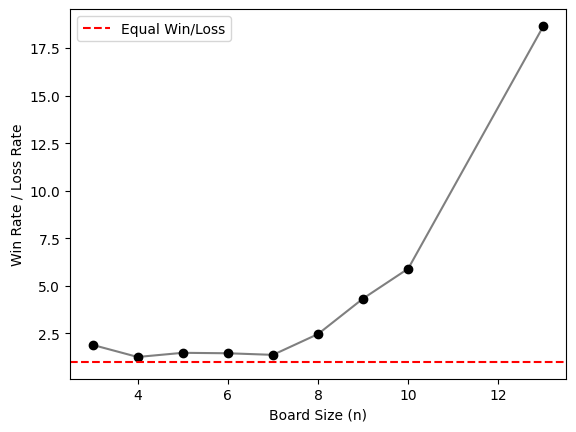

In [11]:
plt.clf()
plt.ylabel("Win Rate / Loss Rate")
plt.xlabel("Board Size (n)")
plt.axhline(y=1, color='r', linestyle='--', label='Equal Win/Loss')
plt.legend()
sorted = np.argsort(ns)
ns = np.array(ns)[sorted]
wrs = np.array(wrs)[sorted]
plt.scatter(ns,wrs,label='DQN', color='black')
plt.plot(ns,wrs,color='black',alpha=0.5)
plt.show()

In [12]:
wrs_subs = []
for subdict in ress:
    wrs_subs.append(100*(subdict['win_rate']-subdict['loss_rate']))

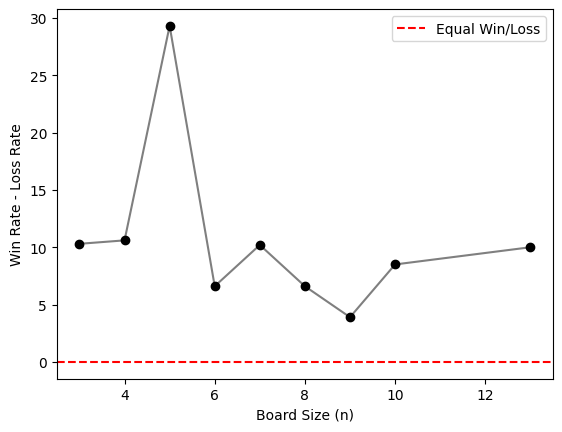

In [13]:
plt.clf()
plt.ylabel("Win Rate - Loss Rate")
plt.xlabel("Board Size (n)")
plt.axhline(y=0, color='r', linestyle='--', label='Equal Win/Loss')
plt.legend()
sorted = np.argsort(ns)
ns = np.array(ns)[sorted]
wrs_subs = np.array(wrs_subs)[sorted]
plt.scatter(ns,wrs_subs,label='DQN', color='black')
plt.plot(ns,wrs_subs,color='black',alpha=0.5)
plt.show()

Learning curves

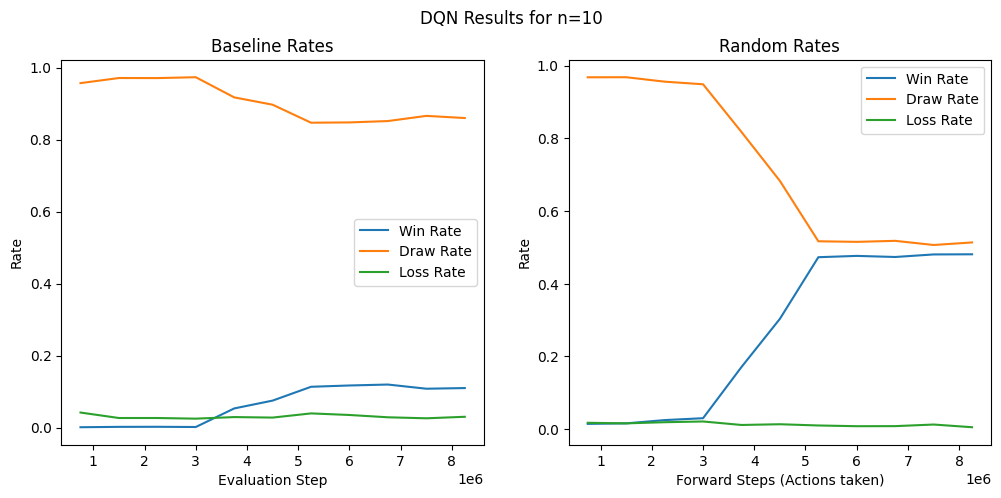

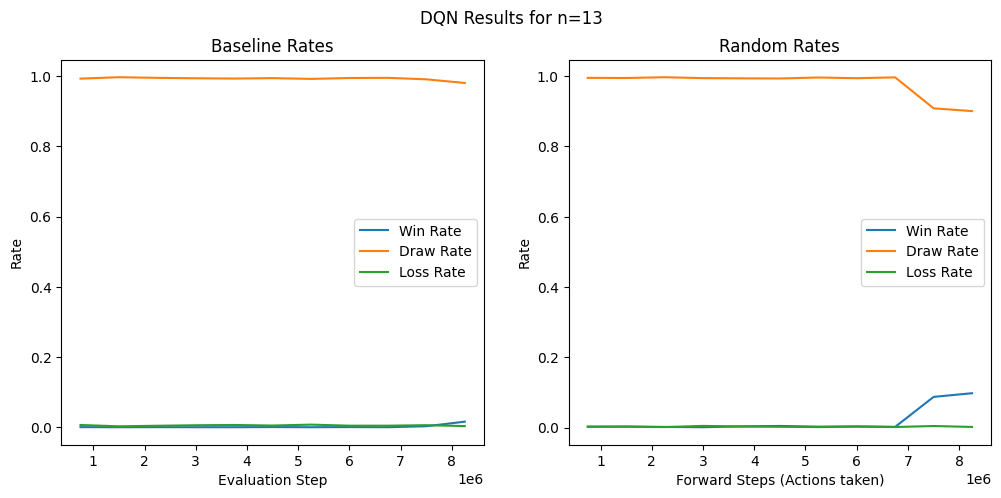

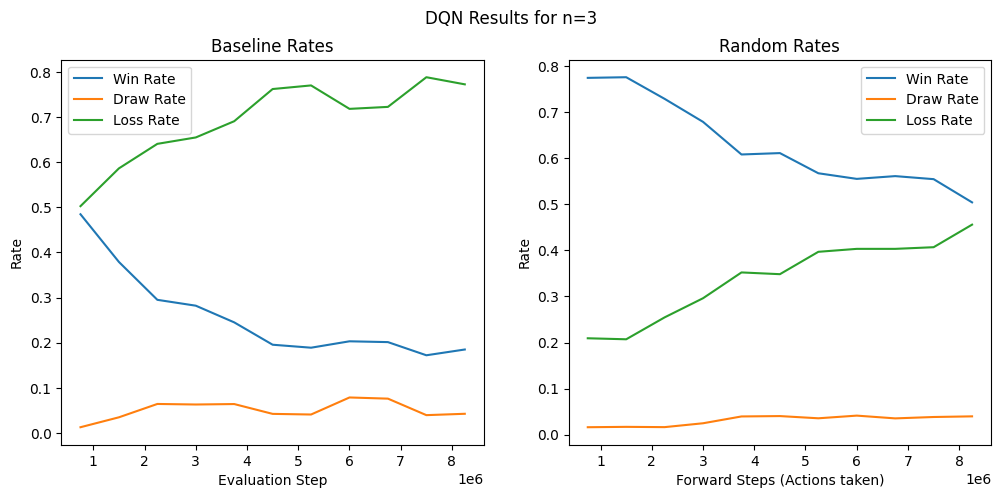

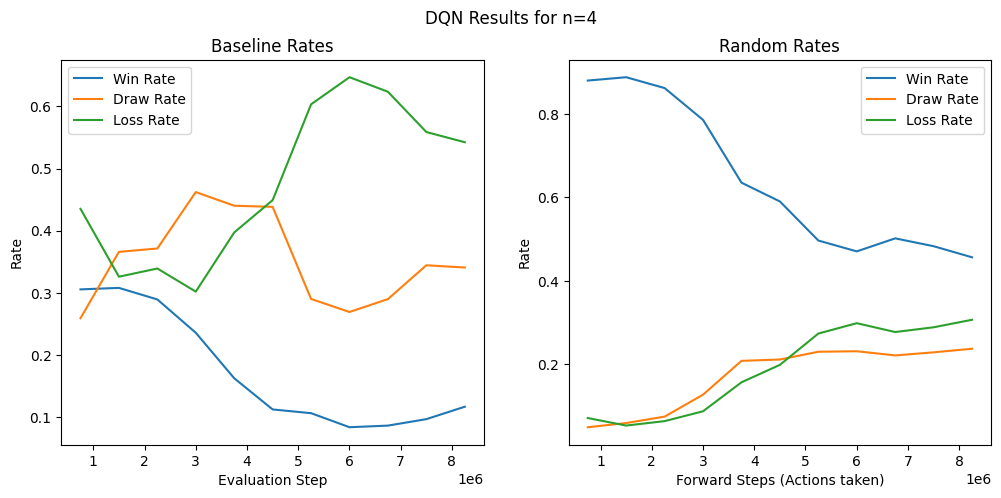

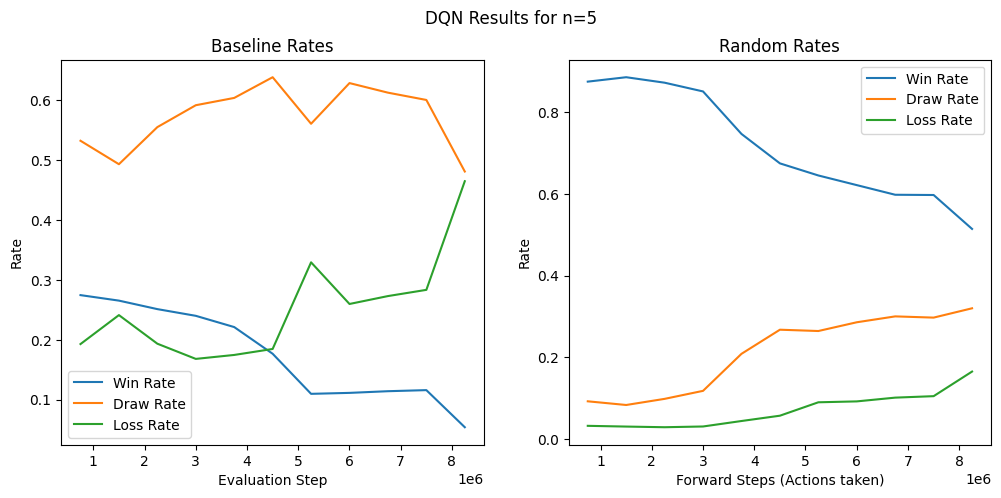

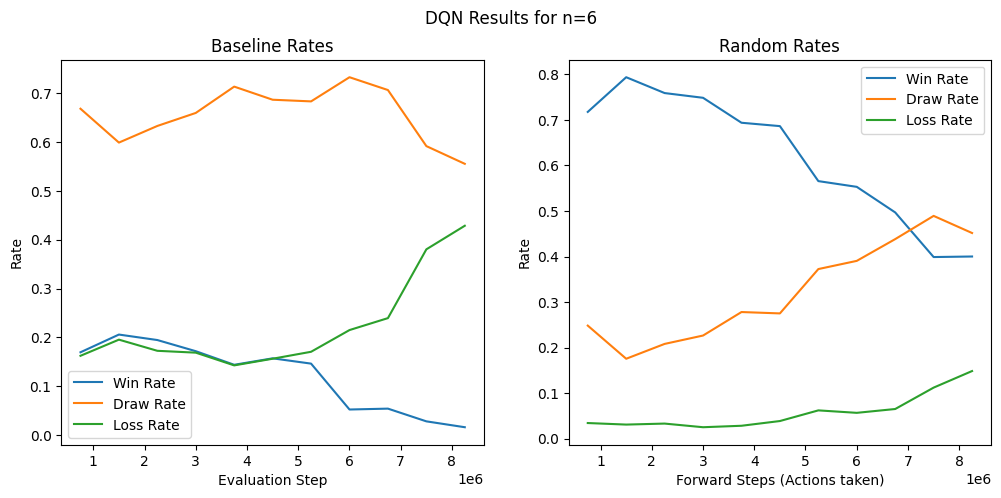

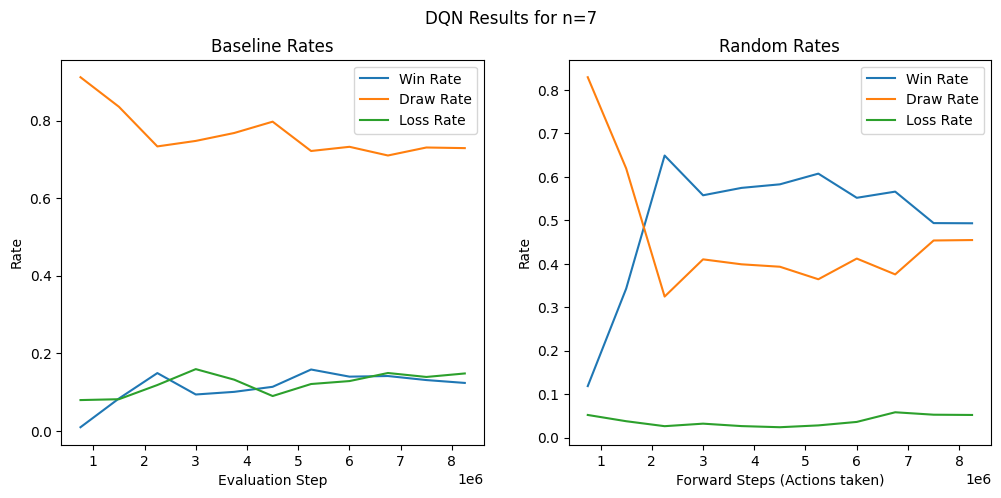

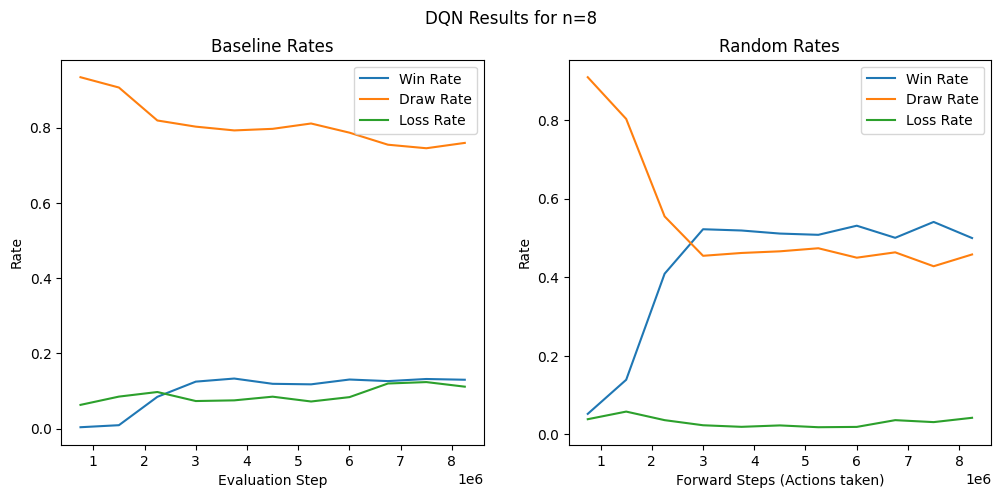

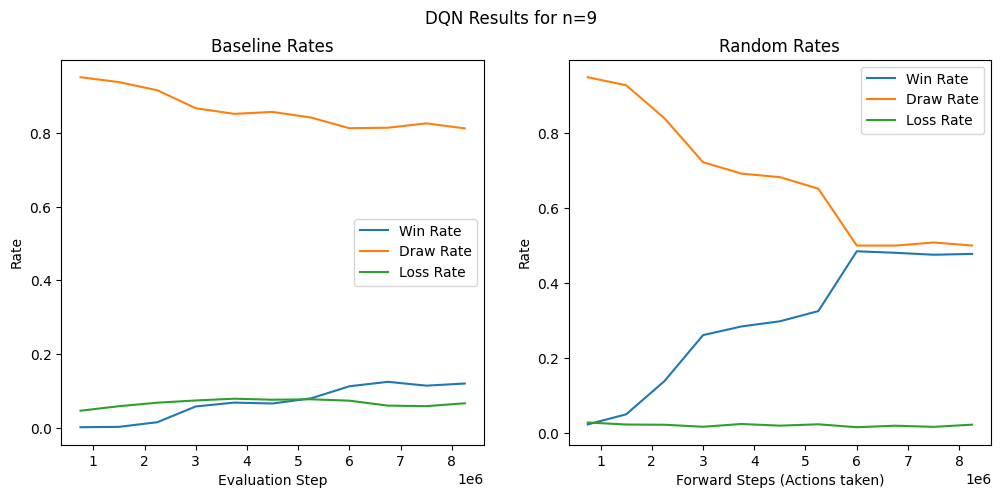

In [14]:
for dir in dirs:
    dir = os.path.join(dir, "tracked_results.pkl")
    n = int(dir.split("/")[-2].split("_")[0])
    
    with open(dir,'rb') as f:
        tracked_results = pickle.load(f)
    plot_results(tracked_results, f"DQN Results for n={n}")

In [15]:
dir

'/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/from_server/DQN/9_1_0.25_winner/tracked_results.pkl'

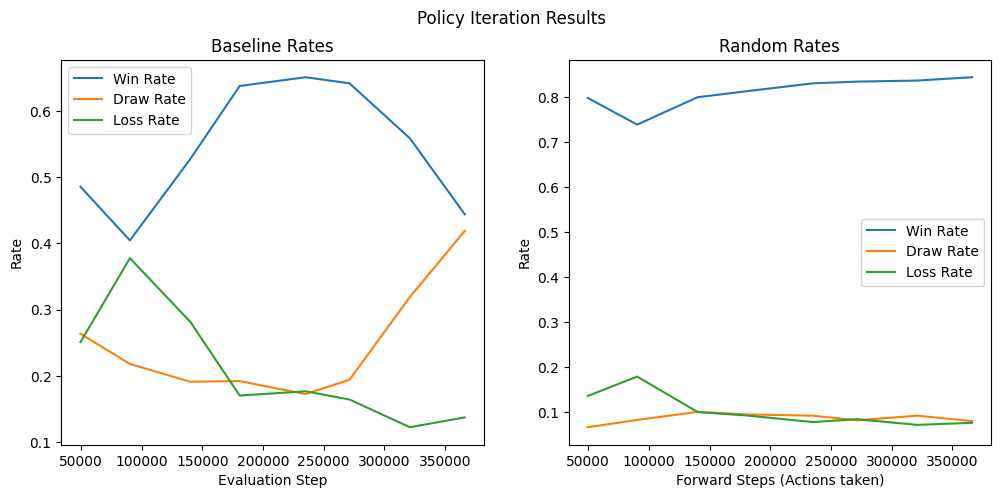

In [16]:
plot_results(all_res[1], "Policy Iteration Results")

In [17]:
#with open("/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/5_1_0.25_winner/tracked_results.pkl", 'rb') as f:
#with open("/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/4_1_0.25_winner/tracked_results.pkl", 'rb') as f:
with open("/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/5_1_0.25_winner/tracked_results.pkl", 'rb') as f:
    tracked_results = pickle.load(f)

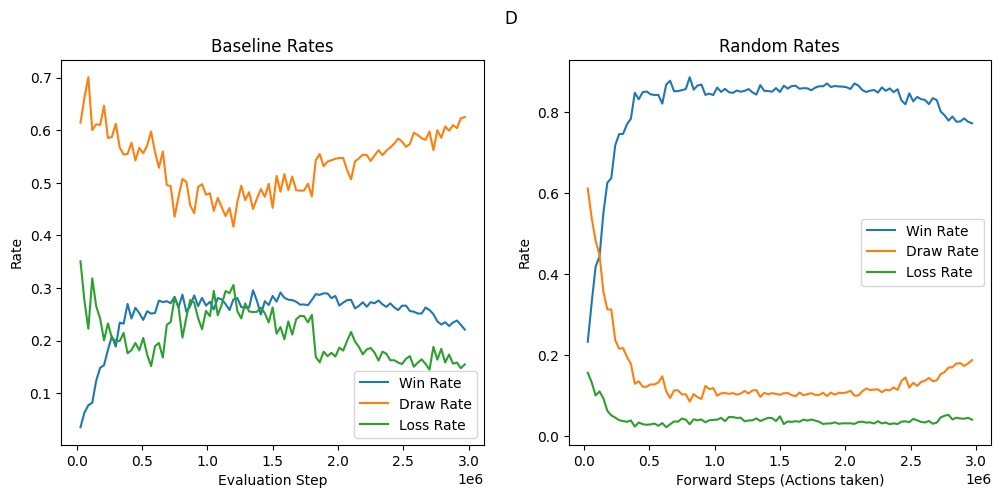

In [18]:
plot_results(tracked_results, "D")

In [19]:
dir = "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/5_1_0.25_winner/q_network.pt"
x_policy = DQNPolicyWrapper(5, dir, player='X')
o_policy = DQNPolicyWrapper(5, dir, player='O')

eval_policy(n=5, x_policy=x_policy, o_policy=o_policy, opponent='baseline', runs=5000, epsilon=0.25)

model loaded
model loaded


{'win_rate': 0.2738, 'draw_rate': 0.5748, 'loss_rate': 0.1514}

In [20]:
0.273/0.1486

1.8371467025572006

# Total plots

In [49]:
def eval(dir,n):
    with open(f"{dir}/temp_policy_x.pkl", "rb") as f:
        x_policy = pickle.load(f)

    with open(f"{dir}/temp_policy_o.pkl", "rb") as f:
        o_policy = pickle.load(f)

    #results_dir = "Policies/VI/3_0.2_0.9_0.25/tracked_results.pkl"
    #with open("Policies/VI/3_0.2_0.9_0.25/tracked_results.pkl", "rb") as f:
    #    tracked_results = pickle.load(f)

    #export_results_to_json(results_dir)

    results_baseline = eval_policy(n=n, x_policy=x_policy, o_policy=o_policy, runs=5000, opponent='baseline',epsilon=0.25)
    results_random = eval_policy(n=n, x_policy=x_policy, o_policy=o_policy, runs=5000, opponent='random',epsilon=0.25)
    print(f"Playing Against Baseline: {results_baseline}")
    print(f"Playing Against Random: {results_random}")

    return results_baseline, results_random

In [ ]:
# value and pi
vi_dirs = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/VI/3_0.2_0.9_0.25", 
           "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/VI/4_0.2_0.9_0.25"]

In [50]:
#VALUE ITER
vi_rates = []
packet = eval(vi_dirs[0],n=3)[0]
vi_rates.append(100*(packet['win_rate'] - packet['loss_rate']))
packet = eval(vi_dirs[1],n=4)[0]
vi_rates.append(100*(packet['win_rate'] - packet['loss_rate']))

Playing Against Baseline: {'win_rate': 0.5448, 'draw_rate': 0.3446, 'loss_rate': 0.1106}
Playing Against Random: {'win_rate': 0.8468, 'draw_rate': 0.0876, 'loss_rate': 0.0656}


In [59]:
# value and pi
pi_dirs = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/PI/3_0.9_0.25"]
#Policy ITER
pi_rates = []
packet = eval(pi_dirs[0],n=3)[0]
pi_rates.append(100*(packet['win_rate'] - packet['loss_rate']))
#packet = eval(vi_dirs[1],n=4)[0]
#pi_rates.append(100*(packet['win_rate'] - packet['loss_rate']))

Playing Against Baseline: {'win_rate': 0.4396, 'draw_rate': 0.4254, 'loss_rate': 0.135}
Playing Against Random: {'win_rate': 0.8318, 'draw_rate': 0.0888, 'loss_rate': 0.0794}


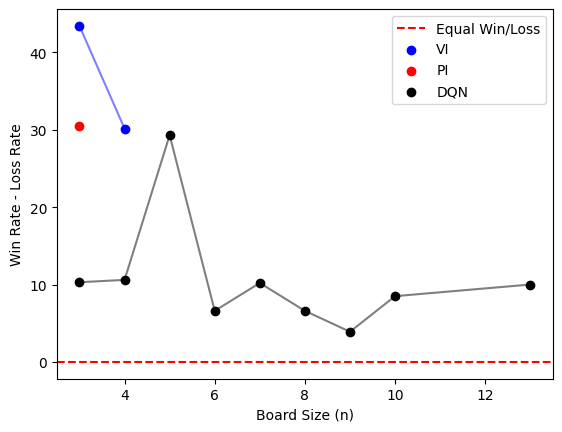

In [60]:
plt.clf()
plt.ylabel("Win Rate - Loss Rate")
plt.xlabel("Board Size (n)")
plt.axhline(y=0, color='r', linestyle='--', label='Equal Win/Loss')
sorted = np.argsort(ns)
ns = np.array(ns)[sorted]
wrs_subs = np.array(wrs_subs)[sorted]

#VI
plt.scatter(ns[:len(vi_rates)],vi_rates,label='VI', color='blue')
plt.plot(ns[:len(vi_rates)],vi_rates, color='blue',alpha=0.5)

#PI
plt.scatter(ns[:len(pi_rates)],pi_rates,label='PI', color='r')
plt.plot(ns[:len(pi_rates)],pi_rates, color='r',alpha=0.5)

plt.scatter(ns,wrs_subs,label='DQN', color='black')
plt.plot(ns,wrs_subs,color='black',alpha=0.5)
plt.legend()
plt.show()

In [133]:
# train curves for n = 3 for now but proably n=4 later

In [134]:
with open("/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/3_1_0.25_winner/tracked_results.pkl", 'rb') as f:
    tracked_results = pickle.load(f)
    
win_rates = np.array([x['win_rate'] for x in tracked_results['baseline_results']])
loss_rates = np.array([x['loss_rate'] for x in tracked_results['baseline_results']])
iters = np.array([x for x in tracked_results['iter_at_eval']])

# iters is [iteration_number, cumulative_actions]
# Use second column directly
iteration_steps = [it[1] for it in iters]
differential = (win_rates - loss_rates)*100


In [143]:
with open("//Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/VI/3_0.2_0.9_0.25/tracked_results.pkl", 'rb') as f:
    tracked_results = pickle.load(f)
    
win_rates_vi = np.array([x['win_rate'] for x in tracked_results['baseline_results']])
loss_rates_vi = np.array([x['loss_rate'] for x in tracked_results['baseline_results']])
iters_vi = np.array([x for x in tracked_results['iter_at_eval']])

# iters_vi is [iteration_number, cumulative_state_updates]
# Use second column directly
iteration_steps_vi = [it[1] for it in iters_vi]
differential_vi = (win_rates_vi - loss_rates_vi)*100


In [144]:
iters_vi

array([[     1,      6],
       [     1,   7200],
       [     1,  20760],
       [     1,  43144],
       [     2,  81924],
       [     2,  89118],
       [     2, 102678],
       [     2, 125062]])

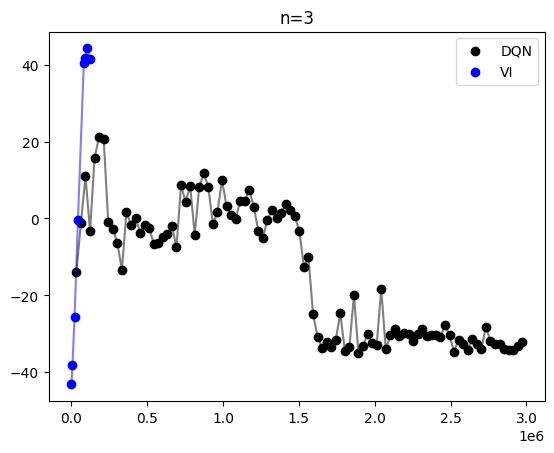

In [149]:
plt.clf()
plt.title("n=3")

#DQN
plt.plot(iteration_steps,differential, color = 'black', alpha=0.5)
plt.scatter(iteration_steps,differential,label='DQN', color = 'black', alpha=1)

#VI
plt.plot(iteration_steps_vi,differential_vi, color = 'blue', alpha=0.5)
plt.scatter(iteration_steps_vi,differential_vi,label='VI', color = 'blue')
plt.legend()
#plt.axis(xmin=0,xmax=0.5e6)
plt.show()